<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_06_Feature_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 06 — Feature Preparation & Categorical Analysis

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 06 is to prepare the dataset for the machine learning
stage by understanding the different types of input features and deciding
how categorical variables should be represented.

The dataset contains both numerical and categorical variables. Machine
learning algorithms generally require categorical information to be converted
into a suitable numerical representation.

### Today's Work

- Load the dataset independently.
- Separate features and target.
- Identify numerical and categorical variables.
- Examine categorical feature cardinality.
- Analyze binary categorical features.
- Analyze multi-category features.
- Identify ordinal features.
- Identify nominal features.
- Decide suitable encoding approaches.
- Check the target variable.
- Create an initial feature-preparation plan.

No machine learning model will be trained today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

df = X.copy()
df["G3"] = y["G3"]

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (649, 31)


In [3]:
# Create project-defined performance categories

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(
    performance_category
)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [4]:
# Separate input features and target variable

target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (649, 31)
Target shape: (649,)

Target distribution:
performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
# Separate input features and target variable

target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (649, 31)
Target shape: (649,)

Target distribution:
performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [7]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [9]:
# Analyze categorical feature cardinality

categorical_cardinality = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Values": [
        X[column].nunique()
        for column in categorical_features
    ]
})

categorical_cardinality = categorical_cardinality.sort_values(
    by="Unique_Values"
)

categorical_cardinality

,Feature,Unique_Values
0,school,2
1,sex,2
2,address,2
3,famsize,2
4,Pstatus,2
11,paid,2
10,famsup,2
9,schoolsup,2
14,higher,2
13,nursery,2


In [10]:
# Inspect values of each categorical feature

for column in categorical_features:
    print("\n" + "=" * 60)
    print("Feature:", column)
    print("Unique values:", X[column].unique())
    print("Number of unique values:", X[column].nunique())


Feature: school
Unique values: ['GP' 'MS']
Number of unique values: 2

Feature: sex
Unique values: ['F' 'M']
Number of unique values: 2

Feature: address
Unique values: ['U' 'R']
Number of unique values: 2

Feature: famsize
Unique values: ['GT3' 'LE3']
Number of unique values: 2

Feature: Pstatus
Unique values: ['A' 'T']
Number of unique values: 2

Feature: Mjob
Unique values: ['at_home' 'health' 'other' 'services' 'teacher']
Number of unique values: 5

Feature: Fjob
Unique values: ['teacher' 'other' 'services' 'health' 'at_home']
Number of unique values: 5

Feature: reason
Unique values: ['course' 'other' 'home' 'reputation']
Number of unique values: 4

Feature: guardian
Unique values: ['mother' 'father' 'other']
Number of unique values: 3

Feature: schoolsup
Unique values: ['yes' 'no']
Number of unique values: 2

Feature: famsup
Unique values: ['no' 'yes']
Number of unique values: 2

Feature: paid
Unique values: ['no' 'yes']
Number of unique values: 2

Feature: activities
Unique val

In [11]:
# Identify binary categorical features

binary_categorical_features = [
    column
    for column in categorical_features
    if X[column].nunique() == 2
]

print("Binary categorical features:")
print(binary_categorical_features)

Binary categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [12]:
for column in binary_categorical_features:
    print(
        f"{column}:",
        X[column].unique()
    )

school: ['GP' 'MS']
sex: ['F' 'M']
address: ['U' 'R']
famsize: ['GT3' 'LE3']
Pstatus: ['A' 'T']
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nursery: ['yes' 'no']
higher: ['yes' 'no']
internet: ['no' 'yes']
romantic: ['no' 'yes']


In [13]:
# Identify categorical features with more than two categories

multi_categorical_features = [
    column
    for column in categorical_features
    if X[column].nunique() > 2
]

print("Multi-category features:")
print(multi_categorical_features)

Multi-category features:
['Mjob', 'Fjob', 'reason', 'guardian']


In [14]:
# Features containing ordered or rating-style values

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

ordinal_summary = pd.DataFrame({
    "Feature": ordinal_features,
    "Minimum": [
        df[column].min()
        for column in ordinal_features
    ],
    "Maximum": [
        df[column].max()
        for column in ordinal_features
    ],
    "Unique_Values": [
        df[column].nunique()
        for column in ordinal_features
    ]
})

ordinal_summary

,Feature,Minimum,Maximum,Unique_Values
0,Medu,0,4,5
1,Fedu,0,4,5
2,traveltime,1,4,4
3,studytime,1,4,4
4,famrel,1,5,5
5,freetime,1,5,5
6,goout,1,5,5
7,Dalc,1,5,5
8,Walc,1,5,5
9,health,1,5,5


In [15]:
for column in ordinal_features:
    print("\n" + "=" * 50)
    print(column)
    print(sorted(df[column].unique()))


Medu
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Fedu
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

traveltime
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

studytime
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

famrel
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

freetime
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

goout
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Dalc
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Walc
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

health
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [16]:
# Nominal categorical features

nominal_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

print("Nominal categorical features:")
print(nominal_features)

Nominal categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']


In [18]:
for column in binary_categorical_features:
    print(
        f"{column}:",
        sorted(df[column].unique())
    )

school: ['GP', 'MS']
sex: ['F', 'M']
address: ['R', 'U']
famsize: ['GT3', 'LE3']
Pstatus: ['A', 'T']
schoolsup: ['no', 'yes']
famsup: ['no', 'yes']
paid: ['no', 'yes']
activities: ['no', 'yes']
nursery: ['no', 'yes']
higher: ['no', 'yes']
internet: ['no', 'yes']
romantic: ['no', 'yes']


In [19]:
# Analyze the classification target

target_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": (
        y.value_counts(normalize=True) * 100
    ).round(2)
})

target_distribution

,Count,Percentage
performance_category,,
Medium,418,64.41
High,131,20.18
Low,100,15.41


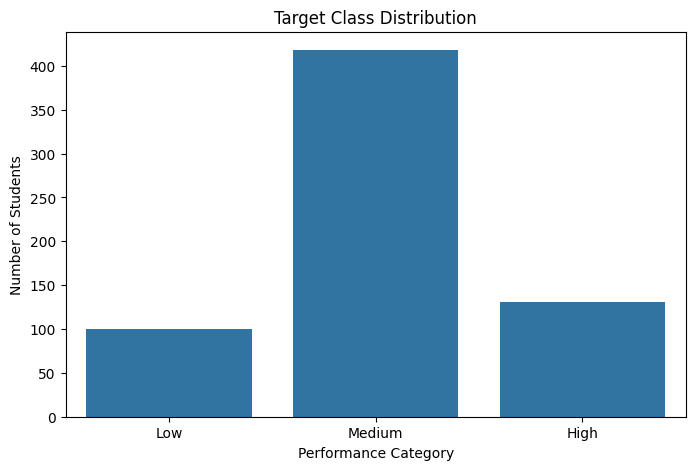

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=y,
    order=["Low", "Medium", "High"]
)

plt.title("Target Class Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

In [21]:
class_counts = y.value_counts()

class_ratio = (
    class_counts.max() / class_counts.min()
)

print("Largest-to-smallest class ratio:",
      round(class_ratio, 2))

Largest-to-smallest class ratio: 4.18


In [22]:
# Check whether the target was derived from any feature

print("Target:", target)
print("G3 present in features:", "G3" in X.columns)

Target: performance_category
G3 present in features: True


In [23]:
# Remove G3 to prevent target leakage

X_model = X.drop(columns=["G3"])

print("Original feature count:", X.shape[1])
print("Feature count after removing G3:", X_model.shape[1])

Original feature count: 31
Feature count after removing G3: 30


In [24]:
# Recalculate feature groups after removing G3

numerical_model_features = X_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_model_features = X_model.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical model features:")
print(numerical_model_features)

print("\nCategorical model features:")
print(categorical_model_features)

Numerical model features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Categorical model features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [26]:
feature_preparation_plan = pd.DataFrame({
    "Feature_Group": [
        "Binary categorical",
        "Nominal categorical",
        "Ordinal numerical-coded",
        "Continuous/count numerical",
        "Target"
    ],
    "Examples": [
        ", ".join(binary_categorical_features),
        ", ".join(nominal_features),
        ", ".join(ordinal_features),
        "age, absences",
        "performance_category"
    ],
    "Planned_Approach": [
        "Encode into numerical representation",
        "One-hot encoding",
        "Retain ordering or evaluate suitable encoding",
        "Keep as numerical features and scale when required",
        "Encode target labels for model training when required"
    ]
})

feature_preparation_plan

,Feature_Group,Examples,Planned_Approach
0,Binary categorical,"school, sex, address, famsize, Pstatus, school...",Encode into numerical representation
1,Nominal categorical,"school, sex, address, famsize, Pstatus, Mjob, ...",One-hot encoding
2,Ordinal numerical-coded,"Medu, Fedu, traveltime, studytime, famrel, fre...",Retain ordering or evaluate suitable encoding
3,Continuous/count numerical,"age, absences",Keep as numerical features and scale when requ...
4,Target,performance_category,Encode target labels for model training when r...


In [27]:
feature_metadata = pd.DataFrame({
    "Feature": X_model.columns,
    "Data_Type": X_model.dtypes.astype(str).values,
    "Unique_Values": [
        X_model[column].nunique()
        for column in X_model.columns
    ],
    "Missing_Values": [
        X_model[column].isnull().sum()
        for column in X_model.columns
    ]
})

feature_metadata

,Feature,Data_Type,Unique_Values,Missing_Values
0,school,object,2,0
1,sex,object,2,0
2,age,int64,8,0
3,address,object,2,0
4,famsize,object,2,0
5,Pstatus,object,2,0
6,Medu,int64,5,0
7,Fedu,int64,5,0
8,Mjob,object,5,0
9,Fjob,object,5,0


In [28]:
print("Feature preparation analysis completed.")

print("\nInput features:", X_model.shape[1])
print("Samples:", X_model.shape[0])
print("Target classes:", y.nunique())

print("\nMissing values in model features:",
      X_model.isnull().sum().sum())

print("\nTarget classes:")
print(y.unique())

Feature preparation analysis completed.

Input features: 30
Samples: 649
Target classes: 3

Missing values in model features: 0

Target classes:
['Medium' 'High' 'Low']


# Day 06 — Feature Preparation Findings

## Feature Types

The dataset contains both numerical and categorical variables. The
categorical variables include binary features such as `sex`, `school`,
`higher`, `internet` and several other yes/no or category-based variables.

Some numerical variables represent ordered categories or rating levels.
Therefore, their numerical data type does not necessarily mean that they
should be treated as ordinary continuous measurements.

## Categorical Features

Categorical variables were divided into binary and multi-category features.
Nominal features such as `Mjob`, `Fjob`, `reason` and `guardian` do not have
a natural numerical order and will require suitable categorical encoding.

## Ordinal Features

Variables such as `studytime`, `traveltime`, `Medu`, `Fedu`, `famrel`,
`freetime`, `goout`, `Dalc`, `Walc` and `health` contain ordered or
rating-style values.

Their ordering needs to be considered during preprocessing.

## Target Variable

The target variable for the classification problem is
`performance_category`.

The target was created from the final grade `G3` using the project's
defined performance thresholds.

## Target Leakage

A target leakage issue was identified during feature preparation.

Since `performance_category` is directly calculated from `G3`, keeping
`G3` as an input feature would allow the model to access information that
directly determines the target.

Therefore, `G3` will be excluded from the machine learning input features.

## Feature Preparation Plan

The identified categorical and numerical feature groups will be prepared
using appropriate preprocessing techniques before model training.

The exact preprocessing pipeline will be implemented and tested in the
next stages of the project.

## Conclusion

Day 06 established the structure of the machine learning input data and
identified the target leakage issue caused by `G3`.

The next stage will focus on implementing the required preprocessing and
encoding techniques.

# DAY 06 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 06 notebook.
- Loaded the Student Performance dataset.
- Recreated the project performance categories.
- Separated the input features and target variable.
- Identified numerical and categorical features.
- Calculated categorical feature cardinality.
- Inspected categorical feature values.
- Identified binary categorical features.
- Identified multi-category features.
- Identified ordinal or rating-style features.
- Identified nominal categorical features.
- Analyzed target-class distribution.
- Checked the relative distribution of target classes.
- Performed a target leakage check.
- Identified that `G3` directly determines `performance_category`.
- Removed `G3` from the machine learning feature set.
- Created a feature preparation plan.
- Created feature metadata for future preprocessing.

## Key Learning

Not every numerical column should automatically be treated as a continuous
numerical feature. The meaning and structure of each variable must also be
considered.

Categorical variables require suitable encoding before most machine learning
algorithms can use them.

## Important Project Decision

The final grade `G3` will not be used as an input feature because the project
target `performance_category` is directly derived from `G3`.

This prevents target leakage and makes the classification task more
meaningful.

## Next Step

Day 07 will focus on implementing categorical encoding and building a
reproducible preprocessing pipeline for the machine learning dataset.